    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
[[-1.1631724  -1.5849703 ]
 [ 2.17018137  0.93098672]
 [ 0.0133054   1.22017719]
 [ 0.20938504  1.07558195]
 [ 0.40546467 -0.48604654]
 [-0.28081405 -0.31253226]
 [ 0.99370357 -0.8330751 ]
 [ 0.99370357  1.8563962 ]
 [ 0.0133054   1.24909623]
 [-0.86905295  2.26126285]]
Confusion Matrix : 
 [[74  5]
 [11 30]]
Coefficients :  [[2.07992926 1.06123725]]
Intercept :  [-0.99843573]
Accuracy :  0.8666666666666667


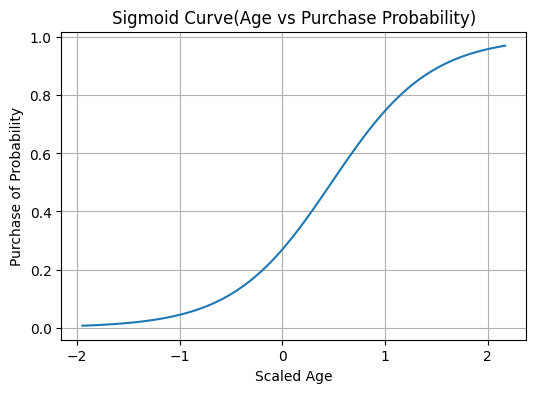

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

data = pd.read_csv("Social_Network_Ads.csv")
print(data.head())

# input
x = data.iloc[:, [2, 3]].values
# output
y = data.iloc[:, 4].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)
print (x_train[0:10, :])

classifier = LogisticRegression(random_state = 0)
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix : \n", cm)
print("Coefficients : ", classifier.coef_)
print("Intercept : ", classifier.intercept_)
print("Accuracy : ", accuracy_score(y_test, y_pred))

age = x_train[:,0]
age_range = np.linspace(age.min(),age.max(),100)
w=classifier.coef_[0][0]
b=classifier.intercept_[0]
z=w*age_range+b
prob = 1/(1+np.exp(-z))

plt.figure(figsize=(6,4))
plt.plot(age_range,prob)
plt.title("Sigmoid Curve(Age vs Purchase Probability)")
plt.xlabel("Scaled Age")
plt.ylabel("Purchase of Probability")
plt.grid()
plt.show()

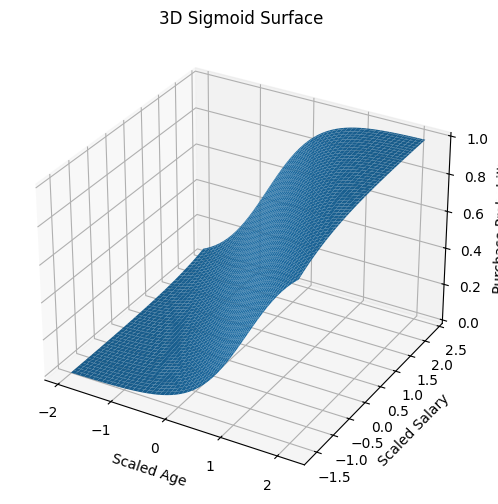

In [31]:
# 3D Sigmoid Surface
from mpl_toolkits.mplot3d import Axes3D

# Create mesh grid
age = np.linspace(x_train[:,0].min(), x_train[:,0].max(), 100)
salary = np.linspace(x_train[:,1].min(), x_train[:,1].max(), 100)
Age, Salary = np.meshgrid(age, salary)

# Get coefficients
w1 = classifier.coef_[0][0]
w2 = classifier.coef_[0][1]
b = classifier.intercept_[0]

# Compute z
Z = w1*Age + w2*Salary + b

# Sigmoid function
Prob = 1 / (1 + np.exp(-Z))

# Plot 3D surface
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Age, Salary, Prob)
ax.set_xlabel("Scaled Age")
ax.set_ylabel("Scaled Salary")
ax.set_zlabel("Purchase Probability")
ax.set_title("3D Sigmoid Surface")
plt.show()

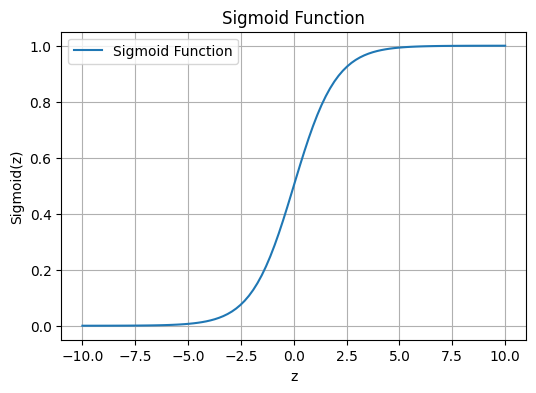

In [32]:
# Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Create values for z
z = np.linspace(-10, 10, 100)

# Plot
plt.figure(figsize=(6,4))
plt.plot(z, sigmoid(z), label='Sigmoid Function')
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.legend()
plt.grid()
plt.show()

Confusion Matrix:
 [[65  3]
 [ 8 24]]
Accuracy: 0.89
Coefficients: [[2.07665837 1.11008221]]
Intercept: [-0.95217247]


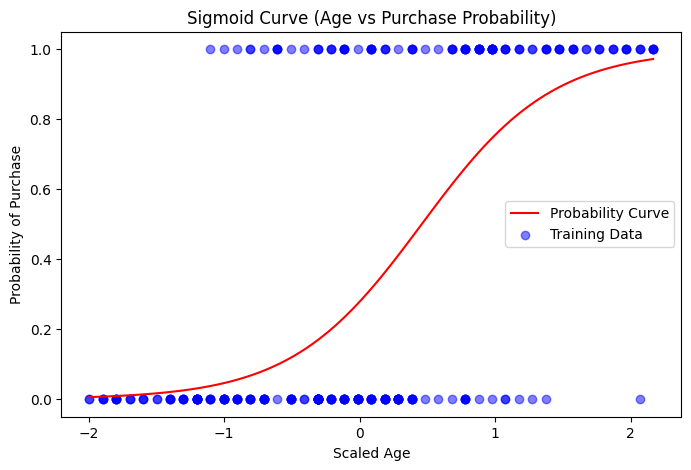

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Create/Load the Data
csv_data = pd.read_csv("Social_Network_Ads.csv")
df = pd.DataFrame(csv_data)


# 2. Input (Age, EstimatedSalary) and Output (Purchased)
# We take columns 2 and 3 for X (Age and EstimatedSalary), and column 4 for y (Purchased)
X = df.iloc[:, [2, 3]].values
y = df.iloc[:, 4].values

# 3. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

# 4. Train Model
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

# 5. Print Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Coefficients:", classifier.coef_)
print("Intercept:", classifier.intercept_)

# 6. Plotting the Sigmoid Curve for Age
# We hold Salary constant at its mean to see how Age alone affects probability
age_range = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)
mean_salary = np.mean(X_train[:, 1])

# Calculate Z: intercept + (w1 * age) + (w2 * mean_salary)
z = classifier.intercept_[0] + (classifier.coef_[0][0] * age_range) + (classifier.coef_[0][1] * mean_salary)
prob = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(age_range, prob, color='red', label='Probability Curve')
plt.scatter(X_train[:, 0], y_train, color='blue', alpha=0.5, label='Training Data')
plt.title("Sigmoid Curve (Age vs Purchase Probability)")
plt.xlabel("Scaled Age")
plt.ylabel("Probability of Purchase")
plt.legend()
